# Python Class 9 — Numerical Computing with NumPy

## Introduction

This class introduces **NumPy**, the core Python library for working with numerical data. Everything in this class builds on the Python fundamentals from Classes 1–8 (variables, lists, loops, and functions), so if any of those feel shaky, it is worth reviewing them first.

### Why NumPy?

Python lists are flexible, but they are not designed for fast, large-scale mathematical operations. **NumPy** provides a specialized array data structure, along with hundreds of built-in functions, that make numerical computing in Python fast, memory-efficient, and easy to read.

### Class Roadmap

**Part A — From Python Lists to NumPy Arrays**
1. The Problem: Predicting Crop Yield
2. Representing the Weights
3. Sample Climate Data for One Region
4. Representing Multiple Regions as Vectors
5. A Manual `crop_yield` Function
6. Installing and Importing NumPy
7. From Python Lists to NumPy Arrays
8. The Dot Product with `np.dot`
9. Why Subtracting Two Python Lists Fails
10. Element-wise Multiplication and `.sum()`
11. Why NumPy Arrays Are Better Than Lists
12. Performance: Loops vs. NumPy

**Part B — Multi-dimensional Arrays**
13. 2D Arrays: Representing All Regions at Once
14. Understanding `.shape`
15. 3D Arrays
16. Data Types with `.dtype`
17. Matrix Multiplication with `np.matmul` / `@`

**Part C — Working with CSV Files**
18. What Is a CSV File?
19. Creating a Reproducible Synthetic Dataset
20. Saving Data with `np.savetxt`
21. Reading Data Back with `np.genfromtxt`
22. Predicting Yields for Thousands of Records at Once
23. Reshaping Arrays with `.reshape()`
24. Combining Arrays with `np.concatenate`
25. Saving Final Results
26. A Quick Reference of Useful NumPy Functions

**Part D — Arithmetic, Broadcasting, and Comparison**
27. Arithmetic Operators on Arrays
28. Array Broadcasting
29. When Broadcasting Fails
30. Array Comparison Operators

**Part E — Indexing and Slicing**
31. Recap: List Indexing vs. Array Indexing
32. Single Element Access in a 3D Array
33. Slicing with Ranges
34. A Common Indexing Mistake

**Part F — Creating Arrays with Built-in Functions**
35. `zeros`, `ones`, and `full`
36. `eye` — the Identity Matrix
37. Random Arrays: `rand` vs. `randn`
38. `arange` and `linspace`

> **Learning rule (same as every earlier class):** run every code cell yourself, read the line-by-line explanation underneath it, and then attempt the practice questions before moving on.

# Part A — From Python Lists to NumPy Arrays

## 1. The Problem: Predicting Crop Yield

Suppose we want to use climate data — temperature, rainfall, and humidity — to estimate the annual yield of apples (in tons per hectare) for a region.

A simple approach is to treat the yield as a **weighted sum** of the three climate factors:

```text
yield_of_apples = w1 * temperature + w2 * rainfall + w3 * humidity
```

This is only an approximation (the real relationship might not be perfectly linear, and other factors may matter too), but a simple linear model like this often works well in practice.

Based on some statistical analysis of historical data, suppose we already know reasonable values for the weights `w1`, `w2`, and `w3`.

In [1]:
w1, w2, w3 = 0.3, 0.2, 0.5

### Line-by-line explanation

1. `w1, w2, w3 = 0.3, 0.2, 0.5` creates three variables in one line. Python assigns each value on the right to the matching variable on the left, in order: `w1` gets `0.3`, `w2` gets `0.2`, and `w3` gets `0.5`.
2. These represent how strongly temperature, rainfall, and humidity each affect the apple yield, according to our (assumed) statistical analysis.

## 2. Sample Climate Data for One Region

Let's record the climate data for **Karachi** as three separate variables, and use our linear formula to predict its apple yield.

In [2]:
karachi_temp = 73
karachi_rainfall = 67
karachi_humidity = 43

### Line-by-line explanation

1. `karachi_temp = 73` stores the average temperature for Karachi (in degrees Fahrenheit, following the original dataset's units).
2. `karachi_rainfall = 67` stores the average rainfall (in millimeters).
3. `karachi_humidity = 43` stores the average relative humidity (as a percentage).

In [3]:
karachi_yield_apples = karachi_temp * w1 + karachi_rainfall * w2 + karachi_humidity * w3
karachi_yield_apples

56.8

### Line-by-line explanation

1. `karachi_temp * w1` multiplies the temperature by its weight.
2. `karachi_rainfall * w2` multiplies the rainfall by its weight.
3. `karachi_humidity * w3` multiplies the humidity by its weight.
4. Adding all three together and storing the result in `karachi_yield_apples` implements our linear formula exactly.
5. Writing `karachi_yield_apples` alone on the last line displays its value (`56.8`) automatically, the same way we saw in earlier classes.

In [4]:
print("The expected yield of apples in Karachi is {} tons per hectare.".format(karachi_yield_apples))

The expected yield of apples in Karachi is 56.8 tons per hectare.


### Line-by-line explanation

1. `.format(karachi_yield_apples)` inserts the value of `karachi_yield_apples` into the `{}` placeholder in the string — this is the `.format()` method from Class 2, applied here to a calculated number instead of a variable holding a name.
2. `print(...)` displays the complete, readable sentence.

### 📝 Practice — 5 questions
1. Create three variables for the climate data of your own city (make up reasonable numbers).
2. Calculate the predicted apple yield for your city using the formula above.
3. Print the result using an f-string instead of `.format()`.
4. Change one weight slightly and observe how the prediction changes.
5. Explain, in your own words, why this is called a "linear" model.

## 3. Representing Multiple Regions as Vectors

To make it easier to repeat this calculation for several regions, we can represent each region's climate data as a **vector** — simply a list of numbers, one for each factor (temperature, rainfall, humidity).

In [5]:
karachi = [73, 67, 43]
lahore = [91, 88, 64]
quetta = [87, 134, 58]
sibi = [102, 43, 37]
hyderabad = [69, 96, 70]

weights = [w1, w2, w3]

### Line-by-line explanation

1. Each line creates a list of three numbers — `[temperature, rainfall, humidity]` — for one city.
2. `weights = [w1, w2, w3]` bundles the three weights into a list as well, in the **same order** as the climate factors in each region's list. This ordering matters: position `0` is always temperature, position `1` is always rainfall, and position `2` is always humidity, in both the region lists and the weights list.

## 4. A Manual `crop_yield` Function

We can now write a reusable function that calculates the yield for **any** region and any set of weights, instead of repeating the formula by hand every time.

In [6]:
def crop_yield(region, weights):
    result = 0
    for x, w in zip(region, weights):
        result += x * w
    return result

### Line-by-line explanation

1. `def crop_yield(region, weights):` defines a function with two parameters: a region's climate list and a weights list.
2. `result = 0` starts a running total at zero.
3. `for x, w in zip(region, weights):` uses `zip()` (from Class 6) to pair up each climate value with its matching weight — the first climate value with the first weight, the second with the second, and so on.
4. `result += x * w` multiplies each pair and adds it to the running total. Over the whole loop, this calculates `temperature*w1 + rainfall*w2 + humidity*w3` — exactly our formula, but written generically for any region.
5. `return result` sends the final total back to whoever called the function.

In [7]:
print("Karachi:", crop_yield(karachi, weights))
print("Lahore:", crop_yield(lahore, weights))
print("Quetta:", crop_yield(quetta, weights))
print("Sibi:", crop_yield(sibi, weights))
print("Hyderabad:", crop_yield(hyderabad, weights))

Karachi: 56.8
Lahore: 76.9
Quetta: 81.9
Sibi: 57.699999999999996
Hyderabad: 74.9


### Line-by-line explanation

1. Each `crop_yield(...)` call passes one region's list and the shared `weights` list.
2. The function repeats the same weighted-sum calculation for each region and returns a single number.
3. `print(...)` displays a label and the predicted yield for that region, one line per city.

### A quick word of caution: mismatched lengths

`zip()` pairs items up **position by position**, and — as you saw in Class 6 — it silently stops at whichever list is shorter. Watch what happens if a region's list has a different length from `weights`.

In [8]:
multan = [95, 40, 35, 12]   # accidentally has 4 values instead of 3

print(crop_yield(multan, weights))

54.0


### Line-by-line explanation

1. `multan = [95, 40, 35, 12]` accidentally has **four** values instead of three — perhaps a typing mistake, or an extra climate factor (say, wind speed) that was added by accident.
2. `weights` still only has **three** values.
3. Inside `crop_yield`, `zip(region, weights)` pairs up values only as far as the **shorter** list allows — so the fourth value in `multan` (`12`) is silently ignored, and the function still runs without any error.
4. This is a genuinely dangerous kind of bug: the code does not crash, but it may silently produce a result based on incomplete data. Always double-check that your data and your weights line up correctly before trusting a calculation like this.

### 📝 Practice — 5 questions
1. Create a list representing the climate data of a sixth city.
2. Use `crop_yield` to calculate its predicted yield.
3. Explain in your own words what `zip()` does inside the `crop_yield` function.
4. Deliberately give `crop_yield` a weights list with only two values and observe what happens.
5. Explain why a silently wrong answer can be more dangerous than a program that crashes.

## 5. Installing and Importing NumPy

Before we can use NumPy, it needs to be installed (most Jupyter and Colab environments already have it, but it is good practice to check).

We can install or upgrade it using the `pip` package manager, directly from a notebook cell, using the same `!` prefix we used for shell commands in Class 5.

In [9]:
!pip install numpy --upgrade

Defaulting to user installation because normal site-packages is not writeable


### Line-by-line explanation

1. `!pip install numpy --upgrade` — the `!` sends this command to the system shell instead of running it as Python (exactly like the `!git` commands in Class 5).
2. `pip install numpy` installs the NumPy library if it is not already present.
3. `--upgrade` makes sure we have the latest available version, even if an older version was already installed.
4. If NumPy is already installed and up to date, this command simply confirms that and does nothing further — it is safe to run every time.

Now let's import the library. By strong convention across the entire data science community, NumPy is imported with the alias `np`.

In [10]:
import numpy as np

### Line-by-line explanation

1. `import numpy` would let us use the library as `numpy.something`.
2. `as np` creates a shorter alias, so we can write `np.something` instead. This is not required by Python, but it is such a universal convention that virtually every NumPy tutorial, textbook, and codebase uses `np`.

## 6. From Python Lists to NumPy Arrays

Right now, `karachi` is a plain Python list.

In [11]:
print(type(karachi))

<class 'list'>


### Line-by-line explanation

1. `type(karachi)` returns `<class 'list'>`, confirming that `karachi` is currently an ordinary Python list, exactly like the lists from Class 4.

NumPy's core data structure is the **array**, created using `np.array()`. Let's convert our lists into NumPy arrays.

In [12]:
karachi = np.array([73, 67, 43])
print(karachi)
print(type(karachi))

[73 67 43]
<class 'numpy.ndarray'>


### Line-by-line explanation

1. `np.array([73, 67, 43])` converts a Python list into a NumPy array containing the same three numbers.
2. `karachi = np.array(...)` overwrites the old plain-list version of `karachi` with this new array version.
3. `print(karachi)` displays the array — visually similar to a list, but it is a different underlying type.
4. `print(type(karachi))` shows `<class 'numpy.ndarray'>`. NumPy arrays always have the type `ndarray` (short for "n-dimensional array").

In [13]:
weights = np.array([w1, w2, w3])
print(weights)
print(type(weights))

[0.3 0.2 0.5]
<class 'numpy.ndarray'>


### Line-by-line explanation

1. `np.array([w1, w2, w3])` converts the weights list into a NumPy array in exactly the same way.
2. Both `karachi` and `weights` are now `ndarray` objects, which is required before we can use NumPy's array-specific operations on them.

Just like Python lists, NumPy arrays support the indexing notation `[]`.

In [14]:
print(weights[0])
print(karachi[1])

0.3
67


### Line-by-line explanation

1. `weights[0]` accesses the first element of the `weights` array, using the same zero-based indexing rule from Class 4.
2. `karachi[1]` accesses the second element of the `karachi` array.
3. Indexing an `ndarray` works exactly the same way as indexing a list.

## 7. The Dot Product with `np.dot`

The calculation performed by our `crop_yield` function — multiplying matching elements together and adding up the results — is called the **dot product** of two vectors. NumPy provides a built-in function, `np.dot`, that computes this directly.

In [15]:
np.dot(karachi, weights)

np.float64(56.8)

### Line-by-line explanation

1. `np.dot(karachi, weights)` multiplies each element of `karachi` with the matching element of `weights`, and adds up all the products — exactly what our manual `crop_yield` function did with a `for` loop, but as a single, direct function call.
2. The result, `56.8`, matches what we calculated by hand earlier in this class.

## 8. Why Subtracting Two Python Lists Fails

It is worth seeing what happens if we try ordinary arithmetic directly on plain Python lists, rather than NumPy arrays.

In [16]:
# We expect this to fail: Python lists do not support element-wise subtraction.
# We wrap it in try/except (Class 8) so we can safely see the error message
# without stopping the rest of the notebook.
try:
    lst1 = [1, 2, 3]
    lst2 = [4, 5, 6]
    lst1 - lst2
except TypeError as e:
    print("TypeError:", e)

TypeError: unsupported operand type(s) for -: 'list' and 'list'


### Why this error happens

Running the cell above prints:

```text
TypeError: unsupported operand type(s) for -: 'list' and 'list'
```

Python lists do not support direct arithmetic like subtraction. The `-` operator, for **element-by-element** subtraction, only works with:

- plain numbers,
- NumPy arrays,
- pandas Series (covered in a later class).

It does **not** work with plain Python lists — this is a genuine limitation, not a mistake in the code above. We caught it with `try`/`except` (from Class 8) so the notebook can keep running normally instead of stopping on this expected error. The fix, if you actually need to subtract two lists, is simply to convert them into NumPy arrays first.

In [17]:
arr1 = np.array([1, 2, 3])
arr2 = np.array([4, 5, 6])

result = arr1 - arr2
print(result)

[-3 -3 -3]


### Line-by-line explanation

1. `np.array([1, 2, 3])` and `np.array([4, 5, 6])` convert both lists into NumPy arrays.
2. `arr1 - arr2` now works, because NumPy arrays support **element-wise** subtraction: `1 - 4`, `2 - 5`, `3 - 6`.
3. `result` stores the new array `[-3, -3, -3]`.
4. `print(result)` displays it. This is one of the biggest practical reasons to convert lists into NumPy arrays before doing math with them.

## 9. Element-wise Multiplication and `.sum()`

We can reproduce the dot product ourselves using two separate, lower-level NumPy operations: element-wise multiplication, followed by `.sum()`.

In [18]:
arr = karachi * weights
print(arr)
print(type(arr))

[21.9 13.4 21.5]
<class 'numpy.ndarray'>


### Line-by-line explanation

1. `karachi * weights` multiplies the two arrays **element by element** (position `0` with position `0`, position `1` with position `1`, and so on), because both arrays have the same shape.
2. The result, `arr`, is itself a new NumPy array containing the three products.
3. `print(type(arr))` confirms it is still an `ndarray`.

In [19]:
print(arr.sum())
print((karachi * weights).sum())

56.8
56.8


### Line-by-line explanation

1. `arr.sum()` adds up all the numbers inside `arr`, giving the same result as `np.dot(karachi, weights)`.
2. `(karachi * weights).sum()` performs the multiplication and the sum in a single expression, without needing the intermediate `arr` variable — the parentheses make sure the multiplication happens before `.sum()` is called on the result.
3. Both lines print the same value, `56.8`, confirming that "multiply element-wise, then sum" is exactly what a dot product means.

### 📝 Practice — 5 questions
1. Convert two lists of your choice into NumPy arrays and add them together.
2. Use `np.dot()` on two arrays of the same length.
3. Reproduce the same dot product using element-wise multiplication and `.sum()`.
4. Try subtracting two plain Python lists directly and read the resulting error message carefully.
5. Explain, in your own words, the difference between `list1 + list2` (which works, but does something different) and `arr1 + arr2` for NumPy arrays.

## 10. Why NumPy Arrays Are Better Than Lists

NumPy arrays offer two major benefits over plain Python lists for numerical work:

- **Ease of use:** short, direct expressions like `(karachi * weights).sum()` replace manual loops and custom functions like `crop_yield`.
- **Performance:** NumPy's internal operations are implemented in C, making them dramatically faster than an equivalent Python `for` loop, especially on large datasets.

Let's see the performance difference directly, by comparing a dot product computed with a plain Python loop against one computed with `np.dot`, on two vectors of one million elements each.

In [20]:
# Plain Python lists
arr1 = list(range(1000000))
arr2 = list(range(1000000, 2000000))

# NumPy arrays containing the same numbers
arr1_np = np.array(arr1)
arr2_np = np.array(arr2)

### Line-by-line explanation

1. `list(range(1000000))` creates a plain Python list containing the numbers `0` through `999999`.
2. `list(range(1000000, 2000000))` creates a second list containing `1000000` through `1999999`.
3. `np.array(arr1)` and `np.array(arr2)` create NumPy-array versions of the same data, so we can compare the two approaches fairly.

In [21]:
%%time
result = 0
for x1, x2 in zip(arr1, arr2):
    result += x1 * x2
result

CPU times: total: 125 ms
Wall time: 119 ms


833332333333500000

### Line-by-line explanation

1. `%%time` is a special Jupyter "cell magic" command. It measures and displays how long the entire cell took to run, right after it finishes. It only works in a Jupyter/IPython environment, not in a plain `.py` script.
2. The `for` loop below it computes the dot product manually, exactly the way `crop_yield` did earlier, but on one million pairs of numbers instead of three.
3. After running this cell, note the reported time (this will typically be several hundred milliseconds, depending on your computer).

In [22]:
%%time
np.dot(arr1_np, arr2_np)

CPU times: total: 0 ns
Wall time: 2.27 ms


np.int64(833332333333500000)

### Line-by-line explanation

1. `%%time` again measures how long this cell takes.
2. `np.dot(arr1_np, arr2_np)` computes the exact same dot product, but using NumPy's internal, C-based implementation instead of a Python `for` loop.
3. Comparing the two reported times, `np.dot` is typically **10 to 100 times faster** than the manual loop. This gap grows even larger as the size of the data grows, which is why NumPy (and libraries built on top of it, like pandas) are essential tools once you start working with large datasets.

### 📝 Practice — 5 questions
1. Repeat the timing comparison with vectors of 10,000,000 elements instead of 1,000,000.
2. Predict, before running it, whether the speed gap will grow or shrink with more data — then check.
3. Explain in your own words why a C-based implementation can be faster than a Python loop.
4. Time how long `sum(arr1)` (Python's built-in `sum`) takes versus `arr1_np.sum()`.
5. Name one real-world situation where this performance difference could matter.

# Part B — Multi-dimensional Arrays

## 11. 2D Arrays: Representing All Regions at Once

So far we have worked with each region's climate data as a separate 1-dimensional array. We can go one step further and combine **all five regions** into a single 2-dimensional array.

In [23]:
climate_data = np.array([[73, 67, 43],
                          [91, 88, 64],
                          [87, 134, 58],
                          [102, 43, 37],
                          [69, 96, 70]])

climate_data

array([[ 73,  67,  43],
       [ 91,  88,  64],
       [ 87, 134,  58],
       [102,  43,  37],
       [ 69,  96,  70]])

### Line-by-line explanation

1. `np.array([[...], [...], [...], [...], [...]])` — passing a **list of lists** to `np.array()` creates a 2-dimensional array, also called a **matrix**.
2. Each inner list becomes one **row**. Here, each row is one region: Karachi, Lahore, Quetta, Sibi, and Hyderabad, in that order.
3. Each **column** represents one climate factor: temperature, rainfall, and humidity, respectively (matching the order we have used throughout this class).
4. Writing `climate_data` on the last line displays the whole matrix, five rows by three columns.

If you have taken a linear algebra class, this is exactly what is meant by a matrix with 5 rows and 3 columns.

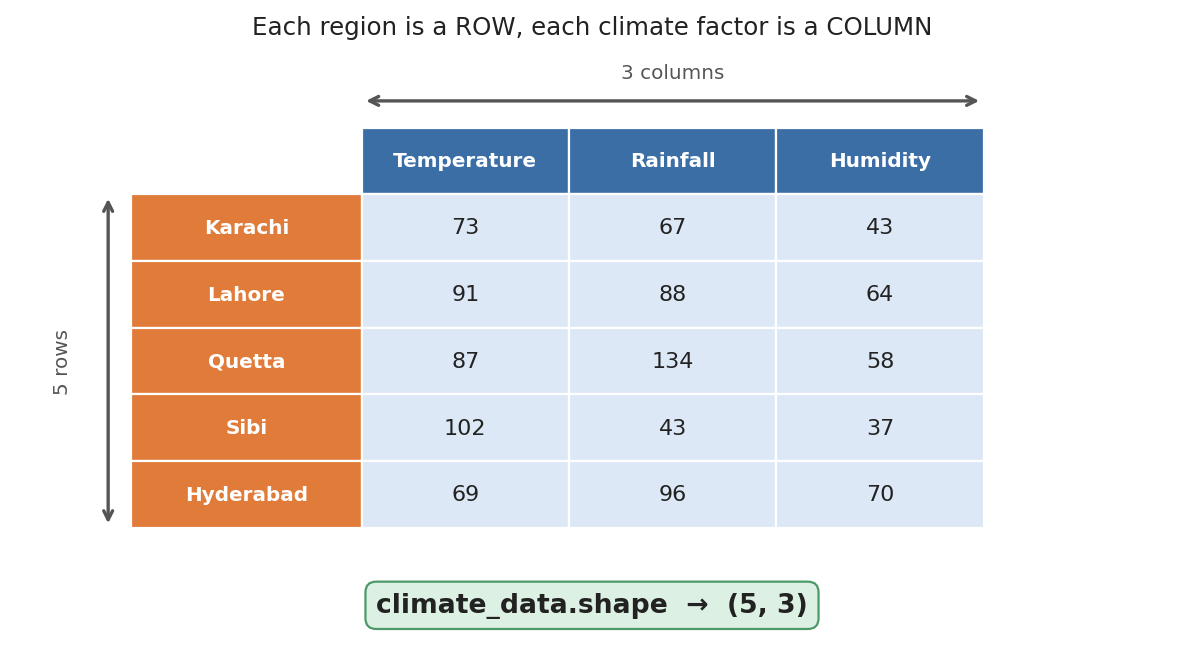

*climate_data as a 2D matrix: each region is a row, each climate factor is a column.*

## 12. Understanding `.shape`

NumPy arrays can have any number of dimensions, and different lengths along each dimension. The `.shape` property tells us exactly how an array is organized.

In [24]:
print(climate_data.shape)   # 2D array (matrix): 5 rows, 3 columns
print(weights.shape)        # 1D array (vector): 3 elements

(5, 3)
(3,)


### Line-by-line explanation

1. `climate_data.shape` returns `(5, 3)` — a tuple (from Class 6) showing that `climate_data` has 5 rows and 3 columns.
2. `weights.shape` returns `(3,)` — a tuple with only one number, because `weights` is a 1-dimensional array (a plain vector) with 3 elements. Note the comma inside `(3,)`: this is exactly the one-item-tuple syntax from Class 6 — without the comma, `(3)` would just be the number `3`.
3. The number of values inside the `.shape` tuple always tells you the number of dimensions of the array: one number means a 1D array (a vector), two numbers mean a 2D array (a matrix), and so on.

## 13. 3D Arrays

NumPy is not limited to 1D or 2D. Here is a 3-dimensional array, built from a list of lists of lists.

In [25]:
arr3 = np.array([
    [[11, 12, 13],
     [13, 14, 15]],

    [[15, 16, 17],
     [17, 18, 19.5]]
])

print(arr3.shape)

(2, 2, 3)


### Line-by-line explanation

1. The outermost list contains **2** items — each of those items is itself a 2D block.
2. Each of those 2D blocks contains **2** rows.
3. Each row contains **3** numbers.
4. So `arr3.shape` reports `(2, 2, 3)` — 2 blocks, each with 2 rows, each with 3 columns.
5. This nested-list-of-lists-of-lists pattern generalizes: NumPy will happily build a 4D, 5D, or higher-dimensional array the same way, as long as the nesting is consistent.

## 14. Data Types with `.dtype`

Every element in a NumPy array shares the **same data type**. The `.dtype` property tells us what that type is.

In [26]:
print(weights.dtype)
print(climate_data.dtype)
print(arr3.dtype)

float64
int64
float64


### Line-by-line explanation

1. `weights.dtype` shows `float64`, because `weights` contains decimal numbers (`0.3`, `0.2`, `0.5`).
2. `climate_data.dtype` shows `int64` (or a similar integer type), because every number used to build it was a whole number.
3. `arr3.dtype` shows `float64` — even though most of the numbers used to build `arr3` were whole numbers, **one single value**, `19.5`, is a decimal. Because a NumPy array must have one consistent type for all its elements, NumPy automatically promotes every element to `float64` as soon as even one floating-point value is present.
4. This is an important rule to remember: **if an array contains even a single floating-point number, every other element is converted to a float too.**

### 📝 Practice — 5 questions
1. Create a 2D array representing three students' scores in three subjects.
2. Print its `.shape` and explain what each number means.
3. Create a 3D array and predict its shape before checking with `.shape`.
4. Create two arrays, one with only integers and one with a mix of integers and a single float, and compare their `.dtype`.
5. Explain in your own words why NumPy insists that every element in an array share the same type.

## 15. Matrix Multiplication with `np.matmul` / `@`

We can now predict the apple yield for **all five regions at once**, using a single matrix multiplication between `climate_data` (a 5×3 matrix) and `weights` (a vector of length 3).

Matrix multiplication can be performed using either the `np.matmul` function or Python's `@` operator, which NumPy repurposes specifically for this operation.

In [27]:
ans = np.matmul(climate_data, weights)
print(ans)
print(ans.shape)

[56.8 76.9 81.9 57.7 74.9]
(5,)


### Line-by-line explanation

1. `np.matmul(climate_data, weights)` multiplies the 5×3 matrix by the length-3 vector, producing one predicted yield **per row** — effectively running the dot-product calculation for every region in a single call.
2. The result, `ans`, is a new array containing 5 numbers, one predicted yield per region.
3. `ans.shape` confirms this: `(5,)`, a 1D array with 5 elements.

In [28]:
climate_data @ weights

array([56.8, 76.9, 81.9, 57.7, 74.9])

### Line-by-line explanation

1. `climate_data @ weights` performs **exactly the same matrix multiplication** as `np.matmul(climate_data, weights)` — the `@` operator is simply a shorter, more mathematical-looking way to write it.
2. Either form is acceptable; `@` is often preferred for readability in longer expressions.

### 📝 Practice — 5 questions
1. Create your own 3×3 matrix and a length-3 vector, and multiply them with `@`.
2. Predict the shape of the result before running the code.
3. Explain why `climate_data @ weights` only works because `climate_data` has exactly 3 columns and `weights` has exactly 3 elements.
4. Try multiplying two matrices together with `@` (both 2D).
5. Compare `np.matmul(a, b)` and `a @ b` on the same two arrays and confirm they give identical results.

# Part C — Working with CSV Files

## 16. What Is a CSV File?

A **CSV (comma-separated values)** file stores tabular data as plain text. Each line is one record, and each record's fields are separated by commas.

For example, a small climate CSV file might look like this:

```text
temperature,rainfall,humidity
25.00,76.00,99.00
39.00,65.00,70.00
59.00,45.00,77.00
84.00,63.00,38.00
```

The first line is usually a **header**, naming each column. NumPy provides built-in functions for both writing and reading files in this format: `np.savetxt()` and `np.genfromtxt()`.

## 17. Creating a Reproducible Synthetic Dataset

Real-world tutorials often download a ready-made data file from the internet. Instead, to keep this notebook fully **self-contained** and reproducible on any computer without needing an internet connection, we will generate an equivalent dataset ourselves, using NumPy's random number tools with a fixed **seed** — the same seed will always produce the same "random" numbers, which is important for reproducibility.

In [29]:
np.random.seed(42)

n_records = 10000

temperature = np.random.uniform(20, 100, n_records)
rainfall = np.random.uniform(10, 150, n_records)
humidity = np.random.uniform(20, 100, n_records)

climate_data_to_save = np.column_stack((temperature, rainfall, humidity))

print(climate_data_to_save.shape)

(10000, 3)


### Line-by-line explanation

1. `np.random.seed(42)` fixes the starting point of NumPy's random number generator. Any number can be used as the seed; what matters is that using the **same seed** always produces the **same sequence** of "random" numbers, so this notebook gives identical results every time it is run.
2. `n_records = 10000` decides how many rows our synthetic dataset will have — matching the size of a realistic dataset.
3. `np.random.uniform(20, 100, n_records)` generates `n_records` random decimal numbers, each uniformly distributed between `20` and `100` — a reasonable range for temperature in Fahrenheit.
4. The same pattern generates plausible ranges for `rainfall` (`10` to `150` millimeters) and `humidity` (`20` to `100` percent).
5. `np.column_stack((temperature, rainfall, humidity))` takes three separate 1D arrays and stacks them **side by side as columns**, producing a single 2D array — exactly the same shape and structure as the `climate_data` matrix we built by hand earlier, but with 10,000 rows instead of 5.
6. `climate_data_to_save.shape` confirms the result: `(10000, 3)`.

## 18. Saving Data with `np.savetxt`

Now let's write this synthetic dataset to an actual CSV file on disk, exactly as if it had been downloaded from somewhere.

In [30]:
np.savetxt('climate.txt',
           climate_data_to_save,
           fmt='%.2f',
           delimiter=',',
           header='temperature,rainfall,humidity',
           comments='')

print("climate.txt has been created.")

climate.txt has been created.


### Line-by-line explanation

1. `'climate.txt'` is the filename NumPy will create (or overwrite) in the current working directory.
2. `climate_data_to_save` is the 2D array being written.
3. `fmt='%.2f'` formats every number to exactly two decimal places, matching the style of a typical CSV climate file.
4. `delimiter=','` tells NumPy to separate each value in a row with a comma, which is what makes this a **comma**-separated values file.
5. `header='temperature,rainfall,humidity'` writes a header line naming each column, at the very top of the file.
6. `comments=''` is important: by default, `np.savetxt` writes the header line starting with `# `, which is the usual "this is a comment" marker. Setting `comments=''` removes that prefix, so the header line reads cleanly as `temperature,rainfall,humidity` rather than `# temperature,rainfall,humidity`.

## 19. Reading Data Back with `np.genfromtxt`

Now we read the CSV file back into a NumPy array — exactly the step a real project would use after downloading a dataset.

In [31]:
climate_data = np.genfromtxt('climate.txt', delimiter=',', skip_header=1)
climate_data

array([[49.96, 62.31, 78.4 ],
       [96.06, 56.61, 34.76],
       [78.56, 34.66, 47.73],
       ...,
       [95.74, 52.52, 21.56],
       [51.8 , 72.06, 52.08],
       [37.37, 34.12, 40.59]], shape=(10000, 3))

### Line-by-line explanation

1. `np.genfromtxt('climate.txt', ...)` reads the file we just created.
2. `delimiter=','` tells NumPy that values in each line are separated by commas — matching how we saved the file.
3. `skip_header=1` tells NumPy to skip the first line (the header with column names), since it contains text, not numbers, and would otherwise cause problems.
4. The result, stored back in `climate_data`, is a fresh 2D NumPy array containing all 10,000 rows of temperature, rainfall, and humidity data — functionally identical to a file that had been downloaded from an external source.

**Important note on reusing the name `climate_data`:** earlier in this class, `climate_data` referred to our small, hand-built 5-row matrix. Here, we deliberately reuse the same variable name for the newly loaded 10,000-row dataset. This mirrors the flow of the original NumPy tutorial this class is based on, but it is worth being consciously aware of: reusing a variable name means the old value is gone. If you wanted both versions available at the same time, you would give them different names, such as `climate_data_sample` and `climate_data_full`.

In [32]:
print(climate_data.shape)

(10000, 3)


### Line-by-line explanation

1. `climate_data.shape` now reports `(10000, 3)` — 10,000 rows (one per record) and 3 columns (temperature, rainfall, humidity), confirming the file was read correctly.

## 20. Predicting Yields for Thousands of Records at Once

We can now apply exactly the same matrix-multiplication idea from Section 15 to predict apple yield for all 10,000 records simultaneously.

In [33]:
weights = np.array([0.3, 0.2, 0.5])

yields_data = climate_data @ weights
print(yields_data.shape)

(10000,)


### Line-by-line explanation

1. `weights = np.array([0.3, 0.2, 0.5])` recreates the weights array (in case its value changed anywhere earlier in the notebook).
2. `climate_data @ weights` multiplies our 10,000×3 matrix by the length-3 weights vector, producing one predicted yield per row — 10,000 predictions calculated in a single expression.
3. `yields_data.shape` confirms the result: `(10000,)`, a 1D array with 10,000 predicted yields.

## 21. Reshaping Arrays with `.reshape()`

`yields_data` is currently a 1D array. To combine it as a new **column** alongside `climate_data`, we first need to reshape it into a 2D array with one column.

In [34]:
yields_column = yields_data.reshape(-1, 1)
print(yields_column.shape)

(10000, 1)


### Line-by-line explanation

1. `.reshape(-1, 1)` reorganizes the same 10,000 numbers into a 2D shape with **1 column**.
2. The `-1` tells NumPy: "figure out this dimension automatically, based on the total number of elements and the other dimension I specified." Since we asked for exactly 1 column, NumPy calculates that the number of rows must be `10000`. This is more robust than hardcoding the number `10000` directly, because it would still work correctly even if the dataset had a different number of rows.
3. `yields_column.shape` confirms the new shape: `(10000, 1)`.

## 22. Combining Arrays with `np.concatenate`

Now let's combine `climate_data` and `yields_column` side by side into one final results table.

In [35]:
climate_results = np.concatenate((climate_data, yields_column), axis=1)
climate_results.shape

(10000, 4)

### Line-by-line explanation

1. `np.concatenate((climate_data, yields_column), axis=1)` joins the two arrays together **along the columns** (`axis=1` means "attach side by side, adding new columns," while `axis=0` would mean "stack on top of each other, adding new rows").
2. For `axis=1` concatenation to work, both arrays must have the **same number of rows** — `climate_data` has 10,000 rows and `yields_column` also has 10,000 rows (which is exactly why we reshaped it in the previous step).
3. The result, `climate_results`, has shape `(10000, 4)` — the original three columns (temperature, rainfall, humidity) plus one new column (predicted yield).

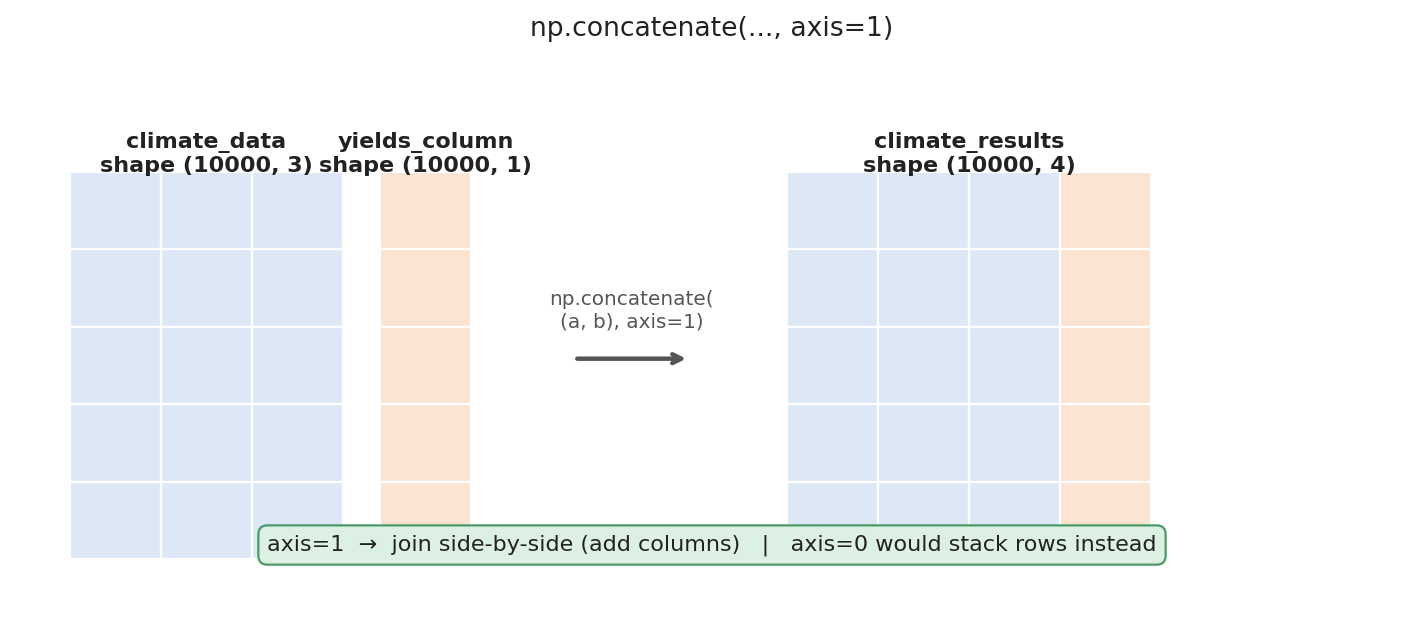

*np.concatenate(..., axis=1) joins two arrays side by side, column-wise.*

## 23. Saving Final Results

Finally, let's write this complete results table — including the predicted yields — back out to a new CSV file.

In [36]:
np.savetxt('climate_results.csv',
           climate_results,
           fmt='%.2f',
           delimiter=',',
           header='temperature,rainfall,humidity,yield_apples',
           comments='')

print("climate_results.csv has been created.")

climate_results.csv has been created.


### Line-by-line explanation

1. This call follows exactly the same pattern as Section 18's `np.savetxt`, but now saves `climate_results` (4 columns) instead of the original 3-column dataset.
2. `header='temperature,rainfall,humidity,yield_apples'` labels the new fourth column correctly. (Note: this header is written as `yield_apples`, correctly spelled — a small but important detail, since a typo in a header name can cause confusion for anyone reading the file later.)
3. The resulting file, `climate_results.csv`, now contains the full input data alongside the model's predictions, ready to be shared, opened in a spreadsheet program, or loaded back into another notebook.

## 24. A Quick Reference of Useful NumPy Functions

NumPy provides hundreds of functions for operating on arrays. Here are some of the most commonly used, grouped by purpose:

| Category | Example functions |
|---|---|
| Mathematics | `np.sum`, `np.exp`, `np.round`, and the usual arithmetic operators |
| Array manipulation | `np.reshape`, `np.stack`, `np.concatenate`, `np.split` |
| Linear algebra | `np.matmul`, `np.dot`, `np.transpose`, `np.linalg.eigvals` |
| Statistics | `np.mean`, `np.median`, `np.std`, `np.max` |

**Finding the right function:** the easiest way to find a NumPy function for a specific task is a web search — for example, searching "how to join numpy arrays" quickly leads to documentation on array concatenation. A full list of NumPy's array functions is available at [numpy.org/doc/stable/reference/routines.html](https://numpy.org/doc/stable/reference/routines.html).

### 📝 Practice — 5 questions
1. Generate your own synthetic dataset of 100 rows with two columns using `np.random.uniform`.
2. Save it to a CSV file using `np.savetxt`.
3. Read it back using `np.genfromtxt` and confirm the shape matches.
4. Add a third column that is the sum of the first two, using `.reshape()` and `np.concatenate`.
5. Save the final combined table to a new CSV file with an appropriate header.

# Part D — Arithmetic, Broadcasting, and Comparison

## 25. Arithmetic Operators on Arrays

NumPy arrays support the usual arithmetic operators — `+`, `-`, `*`, `/`, `%` — directly. You can combine an array with a single number (called a **scalar**), or with another array of the same shape.

In [37]:
arr2 = np.array([[1, 2, 3, 4],
                  [5, 6, 7, 8],
                  [9, 1, 2, 3]])

arr3 = np.array([[11, 12, 13, 14],
                  [15, 16, 17, 18],
                  [19, 11, 12, 13]])

### Line-by-line explanation

1. `arr2` and `arr3` are both 3×4 matrices (3 rows, 4 columns), created the same way as `climate_data` earlier — a list of lists passed to `np.array()`.
2. Because they have the **same shape**, we can perform element-wise arithmetic between them.

In [38]:
print(arr2 + 3)

[[ 4  5  6  7]
 [ 8  9 10 11]
 [12  4  5  6]]


### Line-by-line explanation

1. `arr2 + 3` adds `3` to **every single element** of `arr2`. This is called a **scalar** operation, because `3` is a single number, not an array.
2. NumPy automatically applies the operation to each element — there is no need to write a loop.

In [39]:
print(arr3 - arr2)

[[10 10 10 10]
 [10 10 10 10]
 [10 10 10 10]]


### Line-by-line explanation

1. `arr3 - arr2` subtracts `arr2` from `arr3` **element by element**: the value at row 0, column 0 of `arr2` is subtracted from the value at row 0, column 0 of `arr3`, and so on for every position.
2. This only works because `arr2` and `arr3` have exactly the same shape, `(3, 4)`.

In [40]:
print(arr2 / 2)

[[0.5 1.  1.5 2. ]
 [2.5 3.  3.5 4. ]
 [4.5 0.5 1.  1.5]]


### Line-by-line explanation

1. `arr2 / 2` divides every element of `arr2` by `2`.
2. Just like `a / b` for two numbers (from Class 2), division always returns a Float result, even if the original array contained integers.

In [41]:
print(arr2 * arr3)

[[ 11  24  39  56]
 [ 75  96 119 144]
 [171  11  24  39]]


### Line-by-line explanation

1. `arr2 * arr3` multiplies the two arrays **element by element**, just like `karachi * weights` earlier in this class — this is **not** the same as matrix multiplication (`@`), which follows different rules.

In [42]:
print(arr2 % 4)

[[1 2 3 0]
 [1 2 3 0]
 [1 1 2 3]]


### Line-by-line explanation

1. `arr2 % 4` calculates the remainder of dividing each element by `4`, exactly like the `%` operator on plain numbers from Class 2, but applied to every element at once.

### 📝 Practice — 5 questions
1. Create a 2×3 array and add 10 to every element.
2. Create two 2×3 arrays and multiply them element-wise.
3. Divide an array of your choice by 5.
4. Use `%` to find which elements of an array are even (hint: check where the remainder after dividing by 2 is `0`).
5. Explain the difference between `arr2 * arr3` (element-wise) and `arr2 @ arr3` (matrix multiplication).

## 26. Array Broadcasting

NumPy also supports **broadcasting**: arithmetic between two arrays of **different shapes**, as long as those shapes are compatible. Let's see how it works.

In [43]:
arr2 = np.array([[1, 2, 3, 4],
                  [5, 6, 7, 8],
                  [9, 1, 2, 3]])

print(arr2.shape)

(3, 4)


In [44]:
arr4 = np.array([4, 5, 6, 7])
print(arr4.shape)

(4,)


### Line-by-line explanation

1. `arr2` has shape `(3, 4)` — 3 rows, 4 columns.
2. `arr4` has shape `(4,)` — a 1D array with 4 elements, matching the **number of columns** in `arr2`.

In [45]:
print(arr2 + arr4)

[[ 5  7  9 11]
 [ 9 11 13 15]
 [13  6  8 10]]


### Line-by-line explanation

1. Even though `arr2` and `arr4` have different shapes, this addition works.
2. NumPy "broadcasts" `arr4` — it conceptually repeats `arr4` three times (once per row of `arr2`) to create a matching `(3, 4)` shape, and then adds the two arrays element-wise.
3. Importantly, NumPy does **not** actually create three physical copies of `arr4` in memory — it performs this replication virtually, which keeps broadcasting fast and memory-efficient, even for very large arrays.
4. The general broadcasting rule is: comparing shapes from right to left, two dimensions are compatible if they are **equal**, or if **one of them is 1** (or missing, as in this example where `arr4` effectively has an invisible dimension of size 1 in place of `arr2`'s 3 rows).

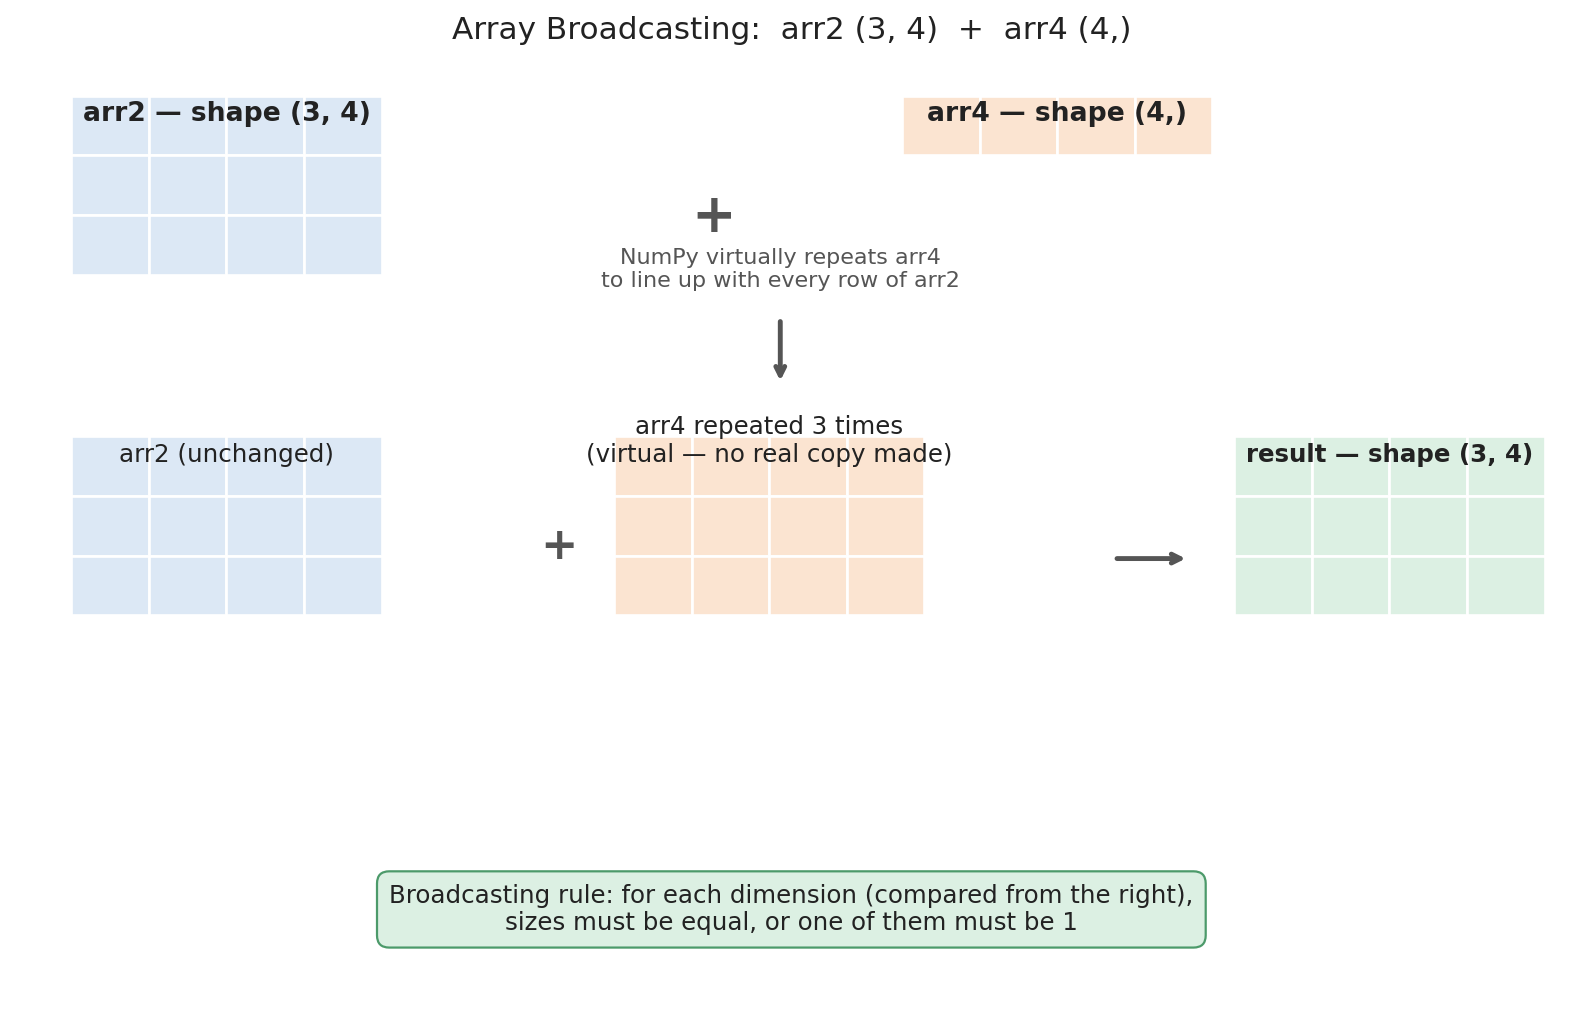

*NumPy broadcasts the smaller array virtually to match the larger array’s shape.*

## 27. When Broadcasting Fails

Broadcasting only works if one array's shape can actually be stretched to match the other's. Let's see what happens when it cannot.

In [46]:
# We expect this to fail: arr5's shape cannot be broadcast to match arr2's shape.
# Wrapping it in try/except lets us inspect the error safely.
arr5 = np.array([7, 8])
print("arr5 shape:", arr5.shape)

try:
    arr2 + arr5
except ValueError as e:
    print("ValueError:", e)

arr5 shape: (2,)
ValueError: operands could not be broadcast together with shapes (3,4) (2,) 


### Why this error happens

Running the cell above prints something like:

```text
ValueError: operands could not be broadcast together with shapes (3,4) (2,)
```

- `arr2` has shape `(3, 4)`.
- `arr5` has shape `(2,)`.

For broadcasting to succeed, comparing the shapes from the right, the sizes in each matching dimension must either be **equal**, or **one of them must be 1**. Here, the last dimension of `arr2` is `4` and the last (only) dimension of `arr5` is `2` — neither are equal, and neither is `1`. There is no sensible way to stretch a 2-element array to line up with 4 columns, so NumPy raises a `ValueError` instead of guessing. We caught it with `try`/`except` so this cell reports the problem cleanly instead of halting the notebook.

The fix is simply to make sure the array you are broadcasting has a size that matches (or is `1` in) the relevant dimension.

In [47]:
arr5_fixed = np.array([1, 2, 3, 4])   # now has 4 elements, matching arr2's 4 columns
print(arr2 + arr5_fixed)

[[ 2  4  6  8]
 [ 6  8 10 12]
 [10  3  5  7]]


### Line-by-line explanation

1. `arr5_fixed` now has exactly 4 elements, matching the number of columns in `arr2`.
2. `arr2 + arr5_fixed` now succeeds, broadcasting `arr5_fixed` across all 3 rows of `arr2`, following the same rule as `arr2 + arr4` earlier.

### 📝 Practice — 5 questions
1. Create a 4×3 array and successfully broadcast-add a 1D array of length 3 to it.
2. Deliberately create a broadcasting error and read the error message carefully.
3. Fix your broadcasting error by adjusting the shape of one of the arrays.
4. Explain, in your own words, the general broadcasting rule (equal, or one of them is 1).
5. Explain why broadcasting is more memory-efficient than manually copying an array to match another array's shape.

## 28. Array Comparison Operators

NumPy arrays also support comparison operators — `==`, `!=`, `>`, `<`, `>=`, `<=` — applied element-wise. The result is always an array of Boolean values (`True`/`False`).

In [48]:
arr1 = np.array([[1, 2, 3], [3, 4, 5]])
arr2 = np.array([[2, 2, 3], [1, 2, 5]])

print(arr1 == arr2)

[[False  True  True]
 [False False  True]]


### Line-by-line explanation

1. `arr1 == arr2` compares the two arrays **position by position**: is `1 == 2`? Is `2 == 2`? And so on, for every element.
2. The result is a new array of the same shape, `(2, 3)`, containing `True` where the two elements matched and `False` where they did not.

In [49]:
print(arr1 != arr2)
print(arr1 >= arr2)
print(arr1 < arr2)

[[ True False False]
 [ True  True False]]
[[False  True  True]
 [ True  True  True]]
[[ True False False]
 [False False False]]


### Line-by-line explanation

1. `arr1 != arr2` flips every result from the `==` comparison: `True` becomes `False` and vice versa.
2. `arr1 >= arr2` checks, element by element, whether the value in `arr1` is greater than or equal to the matching value in `arr2`.
3. `arr1 < arr2` checks the opposite: whether each value in `arr1` is strictly less than the matching value in `arr2`.

Array comparison is frequently combined with `.sum()` to **count** how many elements matched, because in arithmetic, `True` behaves as `1` and `False` behaves as `0`.

In [50]:
print((arr1 == arr2).sum())

3


### Line-by-line explanation

1. `arr1 == arr2` first produces the Boolean array from before.
2. `.sum()` then adds up all the `True`/`False` values, treating each `True` as `1` and each `False` as `0`.
3. The result, `3`, tells us that exactly 3 out of the 6 positions had matching values — a very common and efficient pattern for counting matches without writing a manual loop.

### 📝 Practice — 5 questions
1. Create two arrays of the same shape and compare them with `==`.
2. Count how many elements are equal using `.sum()`.
3. Use `>` to find which elements of one array are bigger than the matching elements of another.
4. Explain why `True` and `False` behave like `1` and `0` in this context.
5. Use a comparison and `.sum()` to count how many elements in an array are greater than a chosen number.

# Part E — Indexing and Slicing

## 29. Recap: List Indexing vs. Array Indexing

From Class 4, indexing a Python list uses `list[index]`, and slicing uses `list[start:stop:step]`.

NumPy extends this same idea to arrays with **any number of dimensions**. Instead of one index, you can provide a **comma-separated list of indices or ranges** — one for each dimension — to select a specific element or a sub-array (called a **slice**).

Let's build a 3D array to explore this.

In [51]:
arr3 = np.array([
    [[11, 12, 13, 14],
     [13, 14, 15, 19]],

    [[15, 16, 17, 21],
     [63, 92, 36, 18]],

    [[98, 32, 81, 23],
     [17, 18, 19.5, 43]]
])

print(arr3.shape)
print(arr3.size)

(3, 2, 4)
24


### Line-by-line explanation

1. This creates a 3D array with **3** outer blocks, each containing **2** rows of **4** numbers.
2. `arr3.shape` confirms this: `(3, 2, 4)`.
3. `arr3.size` returns the **total number of elements** in the array — `3 × 2 × 4 = 24` — regardless of how many dimensions it has. `.size` is different from `.shape`: `.shape` tells you the layout, `.size` tells you the total count.

## 30. Single Element Access

To access one specific number inside a 3D array, provide one index per dimension: `[block, row, column]`.

In [52]:
print(arr3[1, 1, 2])

36.0


### Line-by-line explanation

1. `arr3[1, 1, 2]` means: "go to block index `1`, then row index `1` within that block, then column index `2` within that row."
2. Block `1` is `[[15, 16, 17, 21], [63, 92, 36, 18]]`. Row `1` of that block is `[63, 92, 36, 18]`. Column `2` of that row is `36`.
3. Because all three indices are single numbers (not ranges), the result is a single number, not an array.

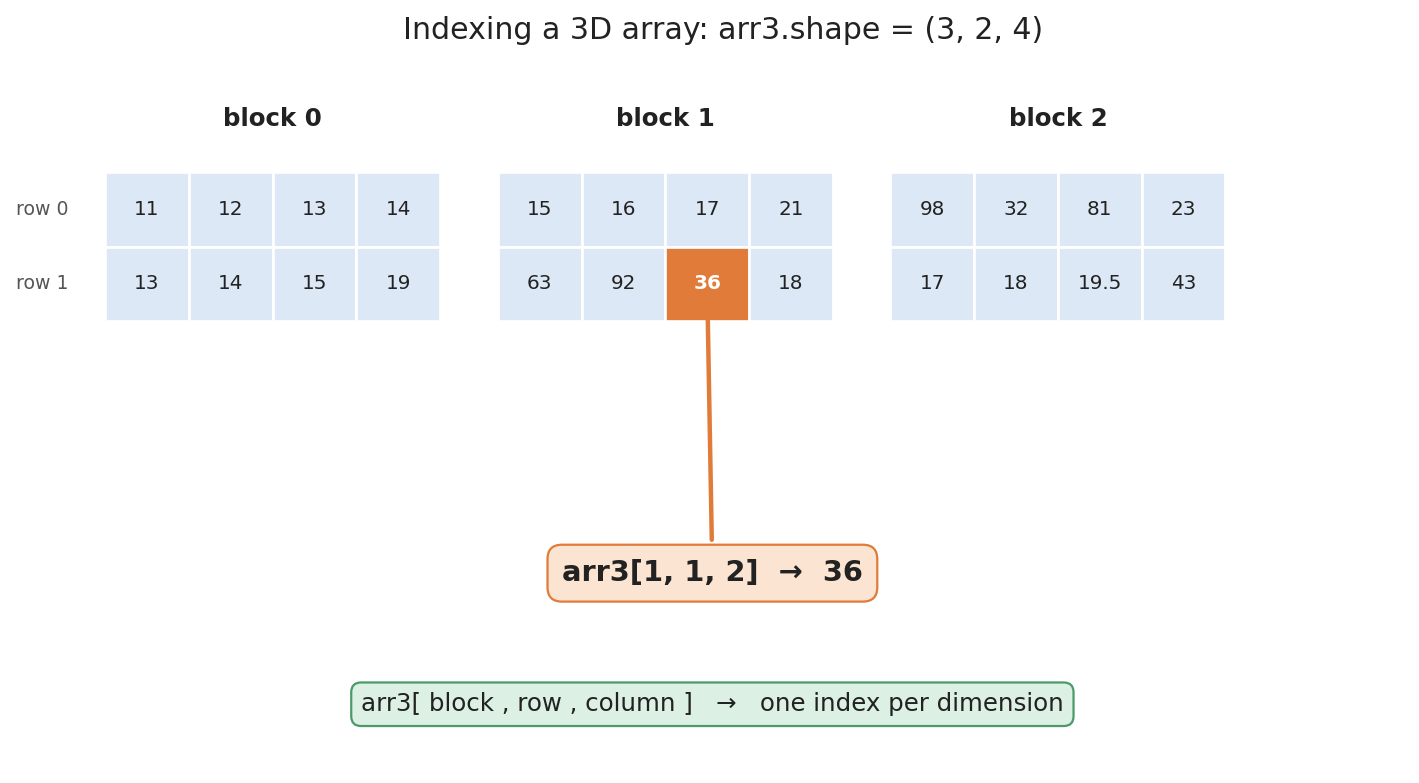

*Indexing a 3D array: one index per dimension collapses that dimension.*

## 31. Slicing with Ranges

Replacing an index with a `start:stop` range keeps that dimension in the result, instead of collapsing it down to a single value.

In [53]:
print(arr3[1:, 0:1, :2])

[[[15. 16.]]

 [[98. 32.]]]


### Line-by-line explanation

1. `1:` for the first dimension means "from block index 1 to the end" — blocks 1 and 2.
2. `0:1` for the second dimension means "row index 0 only" (stop is excluded, exactly like list slicing from Class 4), but because it is written as a **range** rather than a plain index, that dimension is **kept** in the result instead of being removed.
3. `:2` for the third dimension means "columns 0 and 1."
4. The result is a smaller 3D array: 2 blocks, 1 row each, 2 columns each — shape `(2, 1, 2)`.

## 32. Using Fewer Indices Than Dimensions

If you provide fewer indices than the array has dimensions, NumPy simply returns everything along the missing dimensions.

In [54]:
print(arr3[1])

[[15. 16. 17. 21.]
 [63. 92. 36. 18.]]


### Line-by-line explanation

1. `arr3[1]` provides only one index for a 3-dimensional array.
2. NumPy interprets this as "give me block index 1, and everything in the remaining dimensions" — equivalent to `arr3[1, :, :]`.
3. The result is the full 2×4 block at index `1`.

In [55]:
print(arr3[:2, 1])

[[13. 14. 15. 19.]
 [63. 92. 36. 18.]]


### Line-by-line explanation

1. `arr3[:2, 1]` provides a range for the first dimension (blocks 0 and 1) and a single index for the second dimension (row 1 of each of those blocks).
2. The third dimension is not mentioned at all, so NumPy includes it in full.
3. The result contains row 1 from block 0 and row 1 from block 1 — a 2×4 array.

## 33. A Common Indexing Mistake: Too Many Indices

Providing **more** indices than an array has dimensions always raises an error — there is simply nowhere for the extra index to "go."

In [56]:
# We expect this to fail: arr3 has 3 dimensions, but 4 indices are given here.
try:
    arr3[1, 3, 2, 1]
except IndexError as e:
    print("IndexError:", e)

IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed


### Why this error happens

`arr3` has exactly 3 dimensions, but this line provides **4** indices: `1`, `3`, `2`, `1`.

Running it prints:

```text
IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed
```

NumPy checks the **number of indices** against the number of dimensions first, before it even checks whether each individual index is in a valid range. We caught this with `try`/`except` so it prints cleanly rather than stopping the notebook. The fix is always the same: make sure the number of indices (or ranges) you provide matches the number of dimensions the array actually has — check `.shape` if you are ever unsure.

### 📝 Practice — 5 questions
1. Create your own 3D array and predict its `.shape` and `.size` before checking.
2. Access a single element using three indices.
3. Use a range in one dimension and single indices in the others, and predict the resulting shape.
4. Use fewer indices than dimensions and explain what NumPy returns.
5. Deliberately use too many indices and read the resulting error message.

# Part F — Creating Arrays with Built-in Functions

NumPy provides several handy functions for creating arrays of a desired shape, filled with fixed or random values, without needing to type out every element by hand.

## 34. `zeros`, `ones`, and `full`

In [57]:
print(np.zeros((3, 2)))

[[0. 0.]
 [0. 0.]
 [0. 0.]]


### Line-by-line explanation

1. `np.zeros((3, 2))` creates a new array of shape `(3, 2)` — 3 rows, 2 columns — filled entirely with the number `0.0`.
2. This is useful as a starting point when you plan to fill in real values later, one at a time or in a loop.

In [58]:
print(np.ones([2, 2, 3]))

[[[1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]]]


### Line-by-line explanation

1. `np.ones([2, 2, 3])` creates a 3D array of shape `(2, 2, 3)`, filled entirely with `1.0`.
2. Notice the shape can be given as either a tuple `(3, 2)` or a list `[2, 2, 3]` — NumPy accepts both.

In [59]:
print(np.full([2, 3], 42))

[[42 42 42]
 [42 42 42]]


### Line-by-line explanation

1. `np.full([2, 3], 42)` creates a 2×3 array where **every** element is the value `42`.
2. This is a general version of `zeros`/`ones` for any fixed fill value you choose.

## 35. `eye` — the Identity Matrix

An **identity matrix** has `1`s along its main diagonal and `0`s everywhere else. It plays a special role in linear algebra (similar to how the number `1` behaves in ordinary multiplication).

In [60]:
print(np.eye(3))

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### Line-by-line explanation

1. `np.eye(3)` creates a 3×3 identity matrix: `1`s running diagonally from the top-left to the bottom-right, and `0`s everywhere else.
2. Multiplying any compatible matrix by an identity matrix leaves it unchanged — this is analogous to multiplying an ordinary number by `1`.

## 36. Random Arrays: `rand` vs. `randn`

NumPy's `random` module can generate arrays of random numbers. Two commonly confused functions are `np.random.rand` and `np.random.randn`.

In [61]:
print(np.random.rand(5))

[0.63814457 0.45929245 0.96449852 0.21897845 0.58785642]


### Line-by-line explanation

1. `np.random.rand(5)` generates 5 random numbers, each drawn from a **uniform distribution between 0 and 1** — every value in that range is equally likely.
2. Every time you run this cell, you will get different numbers (since we did not set a fixed seed here, unlike Section 17).

In [62]:
print(np.random.randn(2, 3))

[[ 0.88304632  0.54304054  1.67320751]
 [-0.8327369  -0.5849761  -1.78418265]]


### Line-by-line explanation

1. `np.random.randn(2, 3)` generates a 2×3 array of random numbers, but drawn from a **standard normal (bell curve) distribution** — centered around `0`, with most values falling between roughly `-3` and `3`.
2. The key difference: `rand` gives a uniform spread strictly between `0` and `1`; `randn` gives a bell-curve spread centered at `0` that can include negative numbers.

## 37. `arange` and `linspace`

In [63]:
print(np.arange(10, 90, 3))

[10 13 16 19 22 25 28 31 34 37 40 43 46 49 52 55 58 61 64 67 70 73 76 79
 82 85 88]


### Line-by-line explanation

1. `np.arange(10, 90, 3)` works exactly like Python's built-in `range()` from Class 6, but returns a NumPy array instead of a `range` object: start at `10`, stop before `90`, stepping by `3` each time.

In [64]:
print(np.linspace(3, 27, 9))

[ 3.  6.  9. 12. 15. 18. 21. 24. 27.]


### Line-by-line explanation

1. `np.linspace(3, 27, 9)` is different from `arange`: instead of specifying a step size, you specify **how many numbers you want in total** — here, `9`.
2. NumPy calculates the step size automatically so that the 9 numbers are **evenly spaced** between `3` and `27` **inclusive** (unlike `arange`, `linspace` includes the final value by default).
3. This is especially useful when you know exactly how many points you want (for example, to plot a smooth curve), rather than a specific step size.

### 📝 Practice — 5 questions
1. Create a 4×4 array of all zeros.
2. Create a 3×3 identity matrix using `np.eye`.
3. Generate 10 random numbers between 0 and 1 using `np.random.rand`.
4. Use `np.arange` to create every multiple of 5 from 0 to 50.
5. Use `np.linspace` to create exactly 6 evenly spaced numbers between 0 and 100.

# Class 9 — Final Review

## What you should now understand

### From lists to arrays
- Why plain Python lists are not well suited to numerical computation
- How to convert a list into a NumPy array with `np.array()`
- The dot product, and how `np.dot()` replaces a manual loop
- Element-wise arithmetic (`+`, `-`, `*`, `/`, `%`) vs. list behavior
- Why NumPy is dramatically faster than pure Python loops for large datasets

### Multi-dimensional arrays
- 1D, 2D, and 3D arrays, and what `.shape` and `.size` tell you
- Why every element in an array shares one `.dtype`
- Matrix multiplication with `np.matmul` / `@`

### Working with files
- What a CSV file is
- Generating a reproducible synthetic dataset with `np.random.seed`
- Writing data with `np.savetxt` and reading it back with `np.genfromtxt`
- Reshaping with `.reshape(-1, 1)` and combining arrays with `np.concatenate`

### Arithmetic, broadcasting, and comparison
- Scalar and element-wise arithmetic on arrays
- How broadcasting lets arrays of different (but compatible) shapes work together
- What causes a broadcasting error, and how to read that error message
- Comparison operators on arrays, and counting matches with `.sum()`

### Indexing, slicing, and array creation
- Multi-dimensional indexing with comma-separated indices/ranges
- The difference between using a single index (dimension collapses) and a range (dimension is kept)
- Why too many indices raises an `IndexError`
- Creating arrays with `zeros`, `ones`, `full`, `eye`, `rand`, `randn`, `arange`, and `linspace`

## Important scope note

This class covers **NumPy** only. **pandas** (built on top of NumPy, and typically used for labeled, spreadsheet-like data) is intentionally left for its own dedicated class.

## Final Challenge

Using only what you learned in this class, build a small **student performance analyzer**:

1. Create a 2D NumPy array where each row is one student and each column is a subject score.
2. Calculate each student's average score using array operations (no loops).
3. Use a comparison operator and `.sum()` to count how many scores are above 80.
4. Save the array (including a new column for each student's average) to a CSV file using `np.savetxt`.
5. Read the file back using `np.genfromtxt` and confirm it matches what you saved.

**Do not look at earlier examples while solving this — build it yourself, step by step.**

---

## 👨‍💻 About This Course

This **free Python course** was designed and developed by **Muhammad Saad** as a contribution toward making programming education more accessible. I created it to share what I’ve learned with students and beginners who want to learn Python but may not have access to paid courses.

The goal is simple: **to make learning Python easier, accessible, and beginner-friendly.** If this course helps someone learn a new skill or take their first step into programming, then this initiative has achieved its purpose.

If you found this class helpful, feel free to share it with someone who might benefit from it.